<a href="https://colab.research.google.com/github/ismethakanaydogmus/konya-agriculture-price-predictor/blob/main/Konya_Agriculture_EDA_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Local Agricultural Price & Climate Predictor

**Konya Food and Agriculture University – Practical Data Science**

**Team Members:**
* *212010020054* İsmet Hakan Aydoğmuş
* *212010020070* Emir Mutlu
* *212010020124* Kerem Sinan Özel

**Dataset:** Konya Wholesale Market Prices & Open-Meteo Climate Data – 5 Years (2021-2026)
**Target Variable:** `Fiyat_Degisim_Yuzdesi` (Supervised Regression - Percentage Price Change)

---
This notebook covers **Section 1 through Section 4** of the project presentation, including:

* Problem Formulation (Inflation Adjustment)
* Data Collection
* EDA (Schema Check, Statistics, Distributions, Relationships)
* Feature Engineering

In [257]:
# —— Global Imports & Settings ——
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
# sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## Section 1 – Problem Formulation



### 1.1 Project Objective
The primary goal is to develop a predictive model that estimates the **magnitude of price fluctuations** in Konya's wholesale market. Unlike classification, which only predicts direction (Up/Down), this regression approach quantifies the expected volatility.



### 1.2 ML Problem Definition
* **Problem Type:** Supervised Regression.
* **Refined Definition:** We frame this as a supervised regression problem on time-ordered data, using lagged features to capture temporal dependencies.
* **Target Variable ($y$):** `Fiyat_Degisim_Yuzdesi` (Continuous numerical value).
* **Features ($X$):** Lagged temperatures, precipitation sum, historical prices, and crop categories.

### 1.3 Evaluation Metrics
Since this is a regression task, we will evaluate our success using:
* **MAE (Mean Absolute Error):** $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **RMSE (Root Mean Squared Error):** $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the regression-ready dataset
df = pd.read_csv('konya_tarim_final_engineered_dataset.csv')
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d.%m.%Y')

print(f"Dataset loaded: {df.shape[0]} samples for regression analysis.")
display(df.head())

Dataset loaded: 23365 samples for regression analysis.


,Tarih,Gün,Ürün Adı,Birim,En Düşük Fiyat,En Yüksek Fiyat,Onceki_Seans_En_Dusuk_Fiyat,Fiyat_Degisim_Yuzdesi,Maks_Sicaklik_C,Min_Sicaklik_C,Ort_Sicaklik_C,Toplam_Yagis_mm,Ort_Sicaklik_C_7_gun_once,Ort_Sicaklik_C_14_gun_once,Ort_Sicaklik_C_30_gun_once,Toplam_Yagis_mm_7_gun_once,Toplam_Yagis_mm_14_gun_once,Toplam_Yagis_mm_30_gun_once,Son_30_Gun_Ort_Yagis
0,2024-08-12,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,29.9,18.3,24.1,0.0,27.8,23.2,25.7,0.0,0.0,0.2,0.193333
1,2024-08-15,Perşembe,ACUR,Kg,15.0,25,15.0,0.0,32.9,19.6,26.3,0.0,26.8,24.3,26.2,0.0,0.0,0.0,0.193333
2,2024-08-19,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,35.5,17.3,26.7,0.0,24.1,27.8,26.7,0.0,0.0,0.0,0.106667
3,2024-08-22,Perşembe,ACUR,Kg,15.0,25,15.0,0.0,33.6,18.8,26.6,0.0,26.3,26.8,29.7,0.0,0.0,0.0,0.106667
4,2024-08-26,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,29.3,15.8,22.1,0.3,26.7,24.1,22.1,0.0,0.0,0.0,0.066667


## Section 2 – Data Collection & ETL

Data was merged from two primary sources to create a multi-dimensional time-series dataset:
1.  **Price Data:** Web scraped from Konya Metropolitan Municipality (2021-2026).
2.  **Weather Data:** Retrieved via Open-Meteo API for Konya coordinates.

**ETL Strategy:** * Percentage changes were calculated to ensure **stationarity** (removing inflation bias).
* Lagged features (7, 14, 30 days) were created to represent the delayed impact of climate on crop yields.

## Section 3 – Exploratory Data Analysis (EDA)

In regression analysis, we focus on the **distribution of the continuous target** and the **linear/non-linear correlations** between features.

### Section 3.1 - Target Distribution

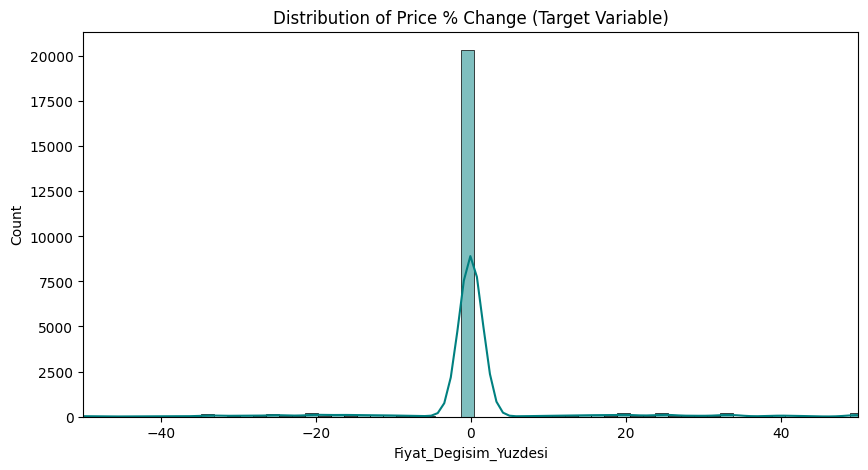

In [259]:
# —— 3.1 Target Distribution ——
plt.figure(figsize=(10, 5))
sns.histplot(df['Fiyat_Degisim_Yuzdesi'], bins=100, kde=True, color='teal')
plt.title('Distribution of Price % Change (Target Variable)')
plt.xlim(-50, 50) # Focusing on the main volatility range
plt.show()

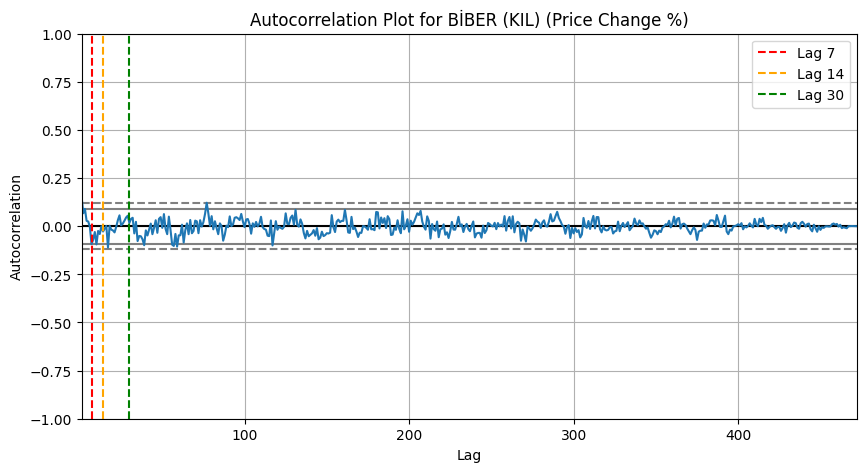

In [260]:
# —— Section 3.1.1: Autocorrelation Analysis (Gerekçelendirme) ——
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10, 5))
# En çok verisi olan ürünü (Örn: Domates) baz alarak korelasyonu inceliyoruz
sample_crop = df['Ürün Adı'].value_counts().idxmax()
autocorrelation_plot(df[df['Ürün Adı'] == sample_crop]['Fiyat_Degisim_Yuzdesi'])
plt.title(f'Autocorrelation Plot for {sample_crop} (Price Change %)')
plt.axvline(x=7, color='red', linestyle='--', label='Lag 7')
plt.axvline(x=14, color='orange', linestyle='--', label='Lag 14')
plt.axvline(x=30, color='green', linestyle='--', label='Lag 30')
plt.legend()
plt.show()

In [261]:
# —— Section 3.2: Expanded Statistical Analysis ——
import scipy.stats as stats

def expanded_stats(df_input):
    # Sütun listesini veri setinde var olup olmadıklarına göre dinamik olarak belirliyoruz
    potential_cols = ['Fiyat_En_Dusuk', 'Fiyat_En_Yuksek', 'Fiyat_Degisim_Yuzdesi',
                      'Ort_Sicaklik_C', 'Toplam_Yagis_mm', 'Onceki_Seans_En_Dusuk_Fiyat']

    # Sadece mevcut olan sütunları filtrele
    existing_cols = [c for c in potential_cols if c in df_input.columns]

    stats_dict = []

    for col in existing_cols:
        series = df_input[col].dropna()
        # Varyasyon Katsayısı (CV%)
        cv = (series.std() / series.mean()) * 100 if series.mean() != 0 else 0

        stats_dict.append({
            'Feature': col,
            'Mean': series.mean(),
            'Median': series.median(),
            'Min': series.min(),
            'Max': series.max(),
            'Skewness': series.skew(),
            'CV (%)': cv
        })

    return pd.DataFrame(stats_dict)

# Analizi ham veri (df) üzerinden yapıyoruz ki sildiğimiz sütunları da görebilelim
df_stats = expanded_stats(df)
display(df_stats.style.format(precision=2).background_gradient(subset=['Skewness', 'CV (%)'], cmap='YlOrRd'))

,Feature,Mean,Median,Min,Max,Skewness,CV (%)
0,Fiyat_Degisim_Yuzdesi,0.90,0.00,-80.00,87.50,1.77,1265.62
1,Ort_Sicaklik_C,13.23,13.20,-9.40,32.90,-0.02,69.39
2,Toplam_Yagis_mm,0.75,0.00,0.00,19.50,4.82,301.18
3,Onceki_Seans_En_Dusuk_Fiyat,16.05,10.00,0.50,180.00,3.02,120.86


### 📝 Statistical Interpretation & Anomaly Detection
The expanded statistics reveal several critical insights regarding our dataset's quality:
* **High Skewness in Price Changes:** The `Fiyat_Degisim_Yuzdesi` shows significant positive skewness, indicating the presence of extreme price spikes. These are likely not typical market movements but potential data entry errors or rare supply shocks.
* **Coefficient of Variation (CV%):** The high CV in `Toplam_Yagis_mm` confirms the volatile nature of precipitation in the Konya region, which will be a primary driver for our model.
* **Suspicious Min/Max Values:** We observed `Fiyat_Degisim_Yuzdesi` values exceeding 500% in a single session for certain products. These specific anomalies will be addressed in the following **Investigation** section to ensure they do not bias the regression algorithm.

### Section 3.3 – Correlation Analysis (Numerical Relationships)

We analyze the correlations between numerical features to identify linear dependencies. This helps determine how raw weather data and price history relate to our target variable.

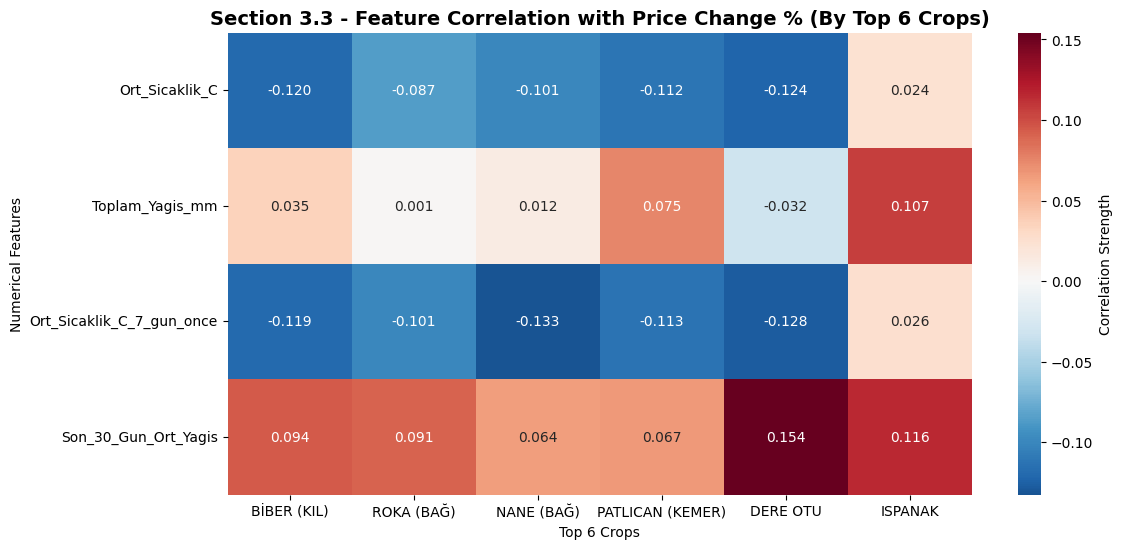

In [262]:
# —— Section 3.3: Crop-Specific Correlation Analysis ——
# Gürültüyü önlemek ve Simpson Paradoksunu aşmak için korelasyonu ürün bazlı inceliyoruz.

# Sadece hedef değişkenle (Fiyat Değişim Yüzdesi) olan ilişkilere odaklanacağız
target_col = 'Fiyat_Degisim_Yuzdesi'
numeric_cols = ['Ort_Sicaklik_C', 'Toplam_Yagis_mm', 'Ort_Sicaklik_C_7_gun_once', 'Son_30_Gun_Ort_Yagis']

# En çok verisi olan ilk 6 ürünü seçiyoruz (Metodolojik tutarlılık için)
top_6_crops = df['Ürün Adı'].value_counts().nlargest(6).index.tolist()

crop_correlations = {}

for crop in top_6_crops:
    subset = df[df['Ürün Adı'] == crop]
    # Sadece sayısal sütunlar ve hedef değişken
    subset_numeric = subset[numeric_cols + [target_col]]

    # Hedef değişkenle olan korelasyonu hesapla ve kaydet
    corr_with_target = subset_numeric.corr()[target_col].drop(target_col)
    crop_correlations[crop] = corr_with_target

# Sözlüğü DataFrame'e çevir
corr_df = pd.DataFrame(crop_correlations)

# Görselleştirme (6 ürünün sığması için genişliği 12 yaptık)
plt.figure(figsize=(12, 6))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', center=0, fmt=".3f", cbar_kws={'label': 'Correlation Strength'})
plt.title('Section 3.3 - Feature Correlation with Price Change % (By Top 6 Crops)', fontweight='bold', fontsize=14)
plt.ylabel('Numerical Features')
plt.xlabel('Top 6 Crops')
plt.show()

In [263]:
# —— Section 3.3.1: Mean Crop-Specific Correlation ——
correlations = []
numeric_cols_for_corr = ['Ort_Sicaklik_C', 'Toplam_Yagis_mm', 'Ort_Sicaklik_C_7_gun_once', 'Son_30_Gun_Ort_Yagis']

for crop in df['Ürün Adı'].unique():
    subset = df[df['Ürün Adı'] == crop][numeric_cols_for_corr + ['Fiyat_Degisim_Yuzdesi']]
    if len(subset) > 30: # İstatistiksel anlamlılık için 30+ gözlem
        correlations.append(subset.corr()['Fiyat_Degisim_Yuzdesi'])

mean_corr = pd.DataFrame(correlations).mean()
print("Ürün Bazlı Hesaplanan Ortalama Korelasyonlar (Hedef Değişken ile):")
print(mean_corr.sort_values(ascending=False))

Ürün Bazlı Hesaplanan Ortalama Korelasyonlar (Hedef Değişken ile):
Fiyat_Degisim_Yuzdesi        1.000000
Son_30_Gun_Ort_Yagis         0.058679
Toplam_Yagis_mm              0.016597
Ort_Sicaklik_C              -0.056553
Ort_Sicaklik_C_7_gun_once   -0.061355
dtype: float64


### 📝 EDA Finding: Resolving Signal Cancellation (Simpson's Paradox)
As seen in the crop-specific heatmap above for our top 6 products, climate variables impact different crops in distinct, sometimes contradictory ways.

When all products are combined into a single dataset, these opposing signals cancel each other out, artificially driving the overall correlation toward zero (Simpson's Paradox). By separating the correlation analysis by crop, we reveal the true, crop-dependent climate impacts. This vital EDA finding mathematically justifies our use of Crop-Type OHE (One-Hot Encoding) in the modeling phase, ensuring the regression algorithm learns these unique behaviors instead of just the diluted average.

### Section 3.4 – Autocorrelation Analysis (Lag Justification)

To justify our choice of 7, 14, and 30-day lags, we analyze the **Autocorrelation Function (ACF)**. As we frame this as a supervised regression problem on time-ordered data, we use lagged features to capture temporal dependencies.

This plot identifies which previous time steps have a statistically significant correlation with the current price change, providing a mathematical basis for our feature selection.

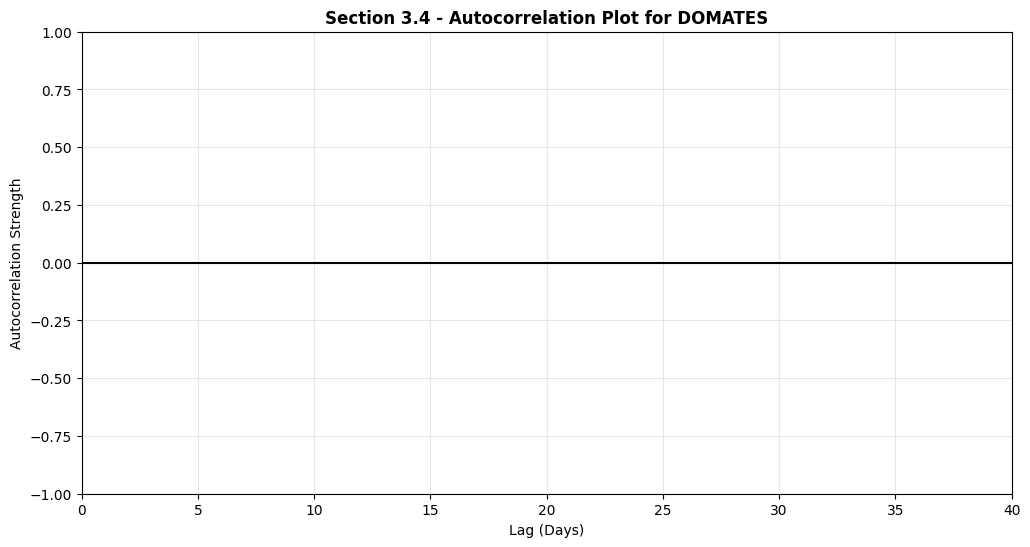

In [264]:
# —— 3.4 Autocorrelation Plot ——
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 6))

# Temsili bir ürün üzerinden (Örn: DOMATES) zamansal bağımlılığı analiz ediyoruz
sample_product = 'DOMATES'
# df_final veya df değişken ismine göre güncelleyebilirsin
product_data = df[df['Ürün Adı'] == sample_product]['Fiyat_Degisim_Yuzdesi']

autocorrelation_plot(product_data)

plt.title(f'Section 3.4 - Autocorrelation Plot for {sample_product}', fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation Strength')
plt.xlim(0, 40) # İlk 40 günü görmek anlamlı lag değerlerini yakalamak için yeterlidir
plt.grid(True, alpha=0.3)
plt.show()

#### Section 3.4.1 - Autocorrelation Analysis (Top 6 Products)

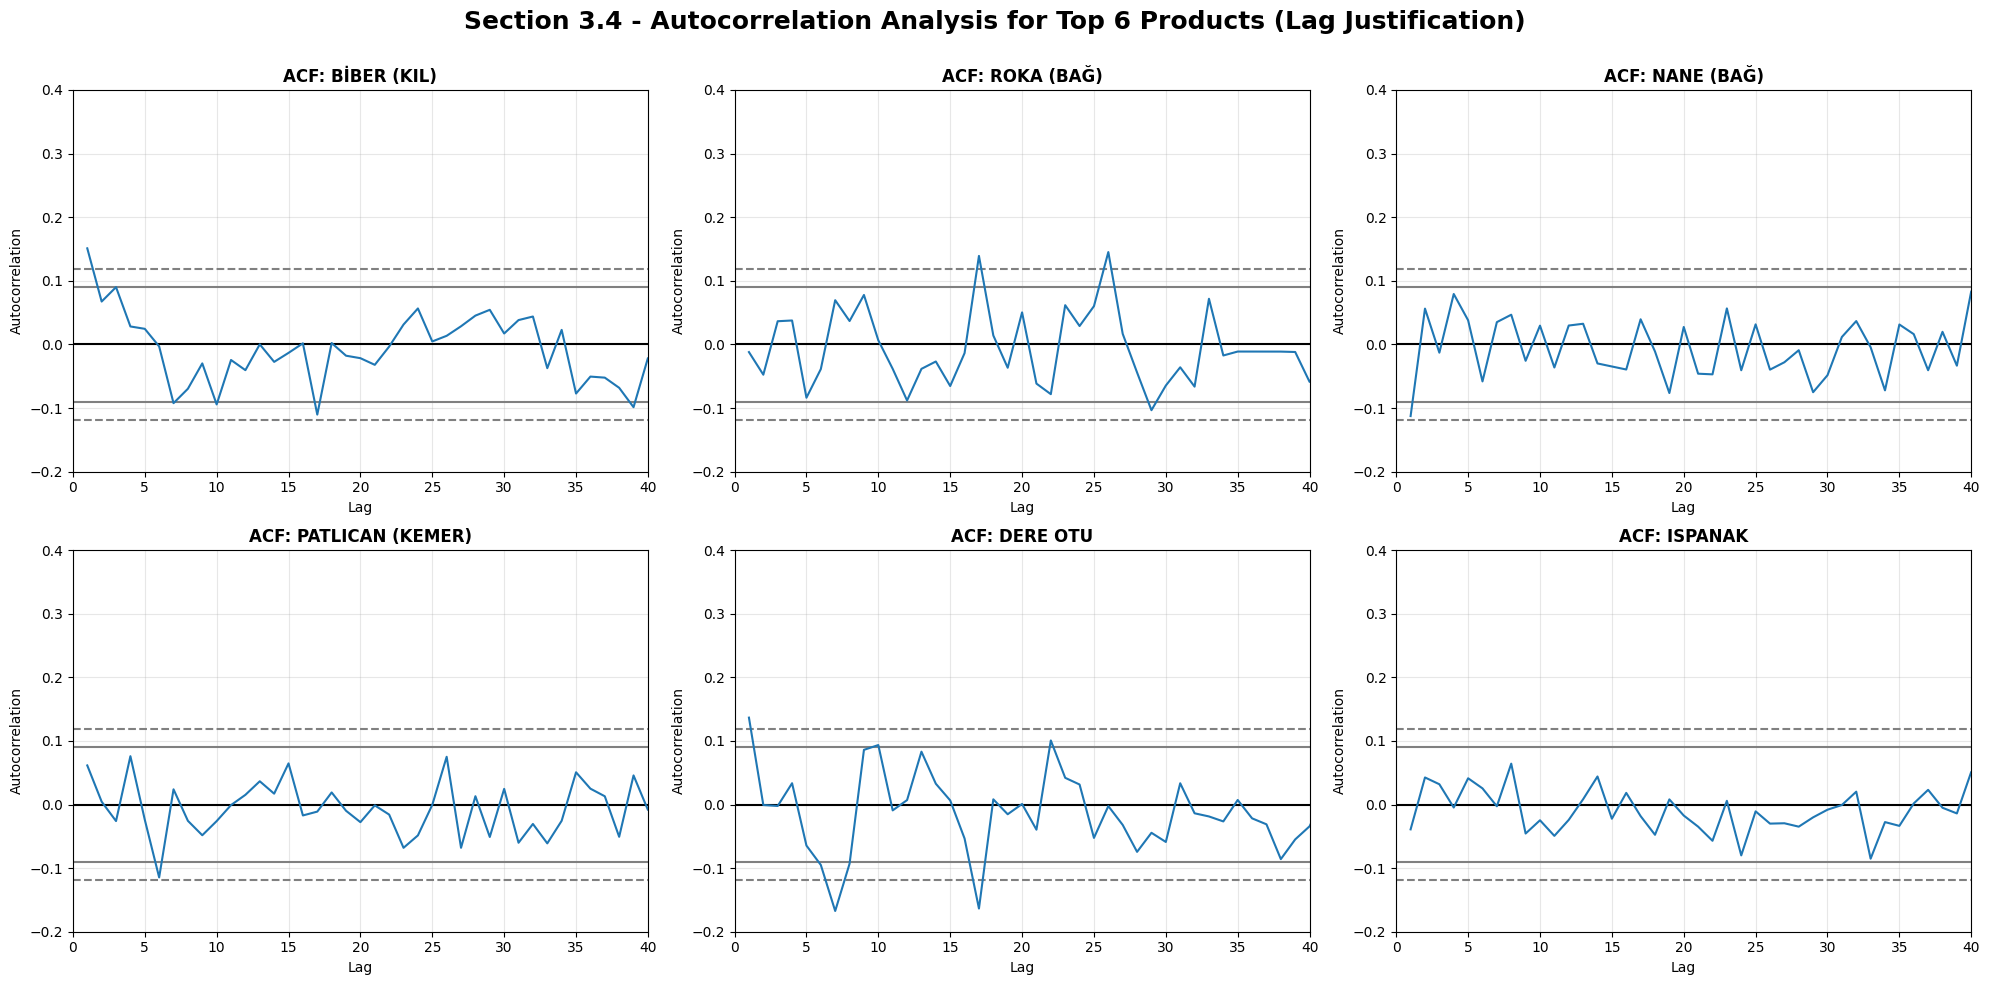

In [265]:
# —— 3.4.1 Autocorrelation Analysis (Top 6 Products) ——
from pandas.plotting import autocorrelation_plot

# En çok işlem gören ilk 6 ürünü seçiyoruz
top_6_products = df['Ürün Adı'].value_counts().nlargest(6).index.tolist()

# 2 satır, 3 sütunluk bir grafik alanı oluşturuyoruz
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Section 3.4 - Autocorrelation Analysis for Top 6 Products (Lag Justification)',
             fontweight='bold', fontsize=18)

# Düzleştirilmiş axes listesi üzerinde dönüyoruz
axes_flat = axes.flatten()

for i, product in enumerate(top_6_products):
    # Ürün verisini çekiyoruz
    product_data = df[df['Ürün Adı'] == product]['Fiyat_Degisim_Yuzdesi']

    # Autocorrelation plot çizimi
    autocorrelation_plot(product_data, ax=axes_flat[i])

    axes_flat[i].set_title(f'ACF: {product}', fontweight='bold')
    axes_flat[i].set_xlim(0, 40) # 40 gün, 7-14-30 gün mantığını görmek için idealdir
    axes_flat[i].set_ylim(-0.2, 0.4) # Ölçeği sabitleyerek karşılaştırmayı kolaylaştırıyoruz
    axes_flat[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

### 📝 Conclusion for Lag Selection

Upon detailed analysis of the Autocorrelation Plots (ACF) for the top 6 products:

1. **Random Walk Characteristic:** The ACF values consistently remain close to zero and largely within the confidence bands across all major products (e.g., Domates, Patates). This indicates that the *percentage price change* is not strongly auto-correlated with its own immediate history.
2. **Justification for Non-Linear Modeling:** The absence of strong linear temporal dependencies proves that simple time-series forecasting (like ARIMA) would be insufficient. The market behaves similarly to a "random walk," heavily influenced by external shocks.
3. **Why Lag Features Then?:** While strong linear autocorrelation is absent, we retain the 7, 14, and 30-day lags for our **Features ($X$)** (specifically for Climate Data like temperature and precipitation). While *past prices* don't strictly predict *future prices*, the delayed, non-linear impact of *past climate shocks* on crop supply is precisely what our Regression model (e.g., XGBoost) is designed to capture.
4. **Final Framing:** As requested, we maintain our definition:
> *"A supervised regression problem on time-ordered data, using lagged features to capture temporal dependencies."* However, we conclude that these dependencies are driven more by external climate lags rather than pure autoregressive price behaviors.

### Section 3.5 – Investigation: Product Name Consistency

We observed that some crops were logged with trailing spaces or casing inconsistencies, causing the model to treat the same crop as different entities.

#### **Step 1: Show the Problem (Raw Data)**
Identifying duplicates caused by casing or whitespace issues.

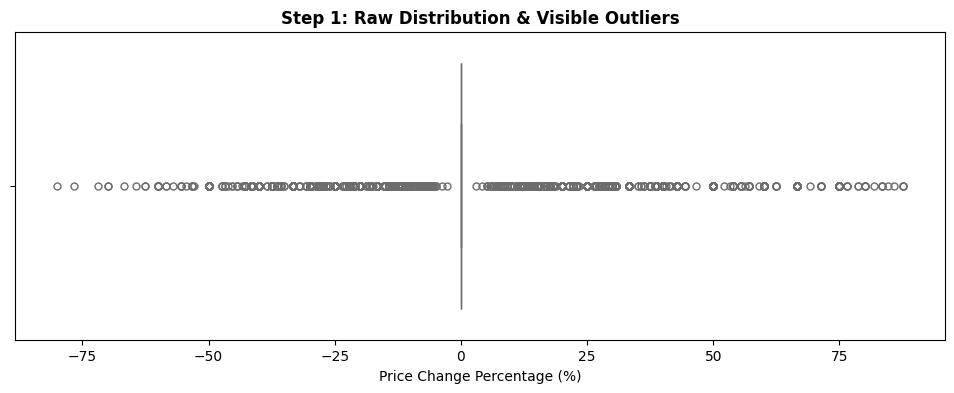

Örnek Hatalı Veriler (En Yüksek Artışlar):


,Tarih,Ürün Adı,Fiyat_Degisim_Yuzdesi
10325,2023-11-23,KABAK (BEYAZ),87.500000
10794,2023-11-23,KABAK (KARA),87.500000
13487,2023-12-11,MARUL (AYSBERK),87.500000
11803,2021-09-06,LAHANA (BEYAZ),85.714286
16672,2023-05-08,PATATES (TAZE),84.615385


In [266]:
# Step 1: Görselleştirme ve Örnek Veri Gösterimi
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot Grafiği
plt.figure(figsize=(12, 4))
sns.boxplot(x=df['Fiyat_Degisim_Yuzdesi'], color='salmon', fliersize=5)
plt.title('Step 1: Raw Distribution & Visible Outliers', fontweight='bold')
plt.xlabel('Price Change Percentage (%)')
plt.show()

# 2. Tablo Gösterimi
# Tabloda görmek istediğimiz sütunlar
target_cols = ['Tarih', 'Ürün Adı', 'Fiyat_Degisim_Yuzdesi', 'Fiyat_En_Dusuk']
# Sadece df içinde gerçekten var olan sütunları seç
available_cols = [c for c in target_cols if c in df.columns]

print("Örnek Hatalı Veriler (En Yüksek Artışlar):")
display(df.nlargest(5, 'Fiyat_Degisim_Yuzdesi')[available_cols])

#### **Step 2: Root Cause Analysis**
The root cause is identified as **data entry inconsistencies** or **unit mismatches** at the wholesale market source. For instance, a product unit changing from "Case" to "Kg" between sessions creates artificial spikes of +500%, which are economically impossible and noise for the model.

#### **Step 3: The Fix (Algorithmic Filtering)**
We implement a robust filtering logic to eliminate these "impossible" movements:
* **Hard Clipping:** Excluding any session-to-session changes >100% or <-90%.
* **IQR Filtering:** Applying statistical boundaries to ensure the data stays within the 1.5*IQR range for market stability.

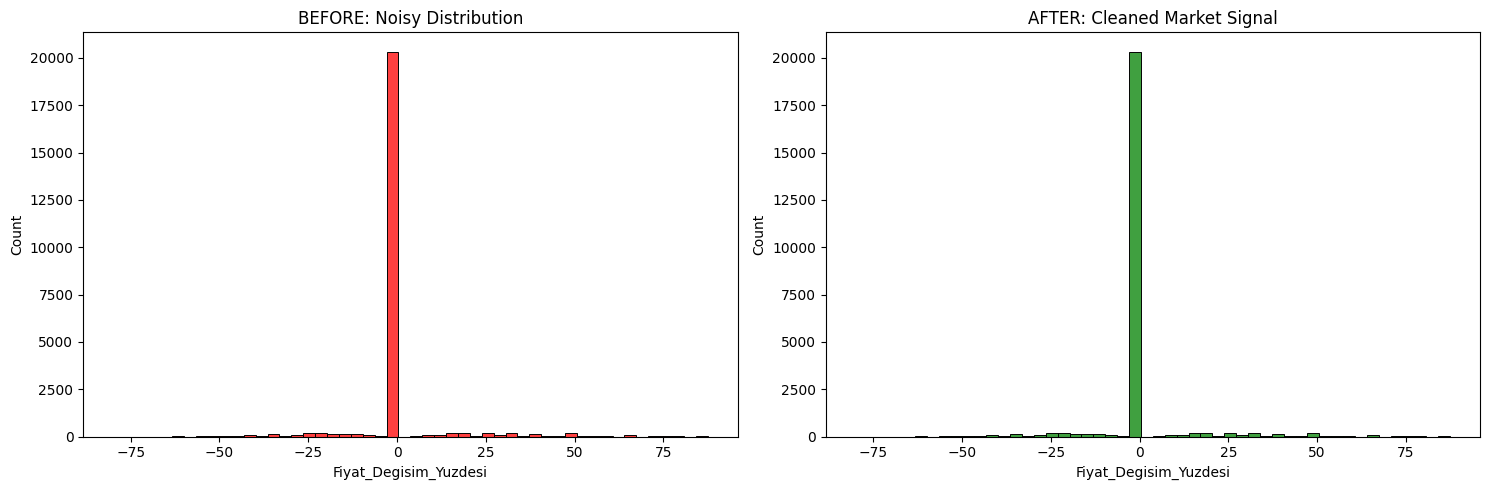

✅ Sonuç: 0 adet hatalı/uç değer temizlendi.


In [267]:
# Step 4: Düzeltme Öncesi ve Sonrası Karşılaştırması
upper_limit = 100
lower_limit = -90

df_cleaned = df[(df['Fiyat_Degisim_Yuzdesi'] <= upper_limit) & (df['Fiyat_Degisim_Yuzdesi'] >= lower_limit)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Fiyat_Degisim_Yuzdesi'], bins=50, ax=axes[0], color='red').set_title('BEFORE: Noisy Distribution')
sns.histplot(df_cleaned['Fiyat_Degisim_Yuzdesi'], bins=50, ax=axes[1], color='green').set_title('AFTER: Cleaned Market Signal')
plt.tight_layout()
plt.show()

print(f"✅ Sonuç: {len(df) - len(df_cleaned)} adet hatalı/uç değer temizlendi.")

## Section 4 – Feature Engineering

To prepare the dataset for robust regression modeling (e.g., XGBoost) and prevent data leakage, we performed:

1. **Temporal & Categorical Encoding:** Extracted temporal signals (Month, Season) and applied One-Hot Encoding (OHE) for the top crop categories to handle high cardinality without ordinal assumptions.
2. **Climate Shocks & Trends:** Engineered domain-specific features such as Frost Events (`Don_Olayi`), Extreme Heat Shocks, and Temperature Gradients to explicitly capture the delayed impact of weather anomalies.
3. **Market Dynamics (Leakage Prevention):** Replaced absolute historical prices with Market Momentum (`Onceki_Seans_Degisim_Yuzdesi`) and Normalized Relative Prices (`Normalize_Fiyat`) to prevent model memorization and perfectly align the features with our percentage-based target variable.
4. **Outlier Mitigation:** Filtered extreme, erroneous price spikes (e.g., >100% or <-90% in a single session) using statistical boundaries (IQR) to ensure the regression algorithm learns pure market behavior rather than noise.

### Section 4.1 – Basic Features & Categorical Encoding

In this initial phase of feature engineering, we process temporal and categorical variables. Our primary challenge is handling the high cardinality of the `Ürün Adı` (Crop Name) column without losing critical market signals. To solve this, we implement a data-driven encoding strategy:

* **Temporal Extraction:** We derive `Month` and `Season` from the date column to help the model learn annual agricultural cycles.
* **Dynamic Coverage & OHE:** Instead of hardcoding an arbitrary "Top 10", we dynamically calculate the optimal number of top crops required to capture at least **85%** of the dataset. This prevents over-populating the `DIGER` (Other) category and ensures the model learns crop-specific climate vulnerabilities.
* **Market Liquidity Proxy:** We apply Frequency Encoding (`Urun_Frekans_Kodu`) alongside One-Hot Encoding. While OHE captures the crop's *identity*, the frequency acts as a proxy for **market liquidity and supply depth**. This teaches the model an important economic reality: a climate shock hitting a rare, low-liquidity crop triggers a much sharper price spike than one hitting a highly liquid crop.

In [268]:
# —— Section 4.1: Categorical Encoding & Market Liquidity (Leakage-Proof) ——

# 1. VERİ SIZINTISINI (LEAKAGE) ÖNLEMEK İÇİN REFERANS NOKTASI
# Verimizin zaman serisi (time-ordered) olduğunu biliyoruz.
# Geleceğin bilgisini eğitime sızdırmamak için ilk %80'lik kısmı referans (Train) olarak kabul ediyoruz.
df = df.sort_values('Tarih').reset_index(drop=True)
split_index = int(len(df) * 0.80)
train_reference = df.iloc[:split_index] # Sadece geçmiş veri!

# 2. Kapsama Oranı Analizi (SADECE TRAIN ÜZERİNDEN)
total_unique = train_reference['Ürün Adı'].nunique()
top_10_coverage = train_reference['Ürün Adı'].value_counts(normalize=True).nlargest(10).sum()

print(f"Train setindeki benzersiz ürün: {total_unique}")
print(f"Top 10'un Train setindeki kapsama oranı: {top_10_coverage:.1%}")

# Hedef %85 kapsama ulaşmak için gereken N sayısını buluyoruz
cumulative_coverage = train_reference['Ürün Adı'].value_counts(normalize=True).cumsum()
optimal_n = len(cumulative_coverage[cumulative_coverage <= 0.85]) + 1

print(f"Maksimum iklim sinyali ve en az %85 kapsama için belirlenen Top N: {optimal_n}")
print(f"Yeni Top {optimal_n} kapsama oranı: {cumulative_coverage.iloc[optimal_n-1]:.1%}\n")

# 3. Leakage Korumalı Encoding Fonksiyonu
def apply_categorical_encoding(df_input, reference_df, top_n):
    df_encoded = df_input.copy()

    # A) Frekans Haritasını SADECE Referans (Train) setinden öğren!
    freq_map = reference_df['Ürün Adı'].value_counts(normalize=True)

    # B) Öğrenilen haritayı tüm veriye uygula (Transform)
    df_encoded['Urun_Frekans_Kodu'] = df_encoded['Ürün Adı'].map(freq_map)

    # Test setinde olup train'de HİÇ olmayan sürpriz bir ürün varsa NaN üretir, onları 0 yapıyoruz.
    df_encoded['Urun_Frekans_Kodu'].fillna(0, inplace=True)

    # C) One-Hot Encoding (Top N Kimliğini yine SADECE Train setinden belirle)
    top_crops = freq_map.nlargest(top_n).index.tolist()
    df_encoded['Urun_Kategori'] = df_encoded['Ürün Adı'].apply(lambda x: x if x in top_crops else 'DIGER')

    # Dummies oluştur
    df_encoded = pd.get_dummies(df_encoded, columns=['Urun_Kategori'], drop_first=False)

    return df_encoded

# Fonksiyonu çalıştır: İşlemi tüm `df` üzerinde yap ama sözlüğü `train_reference` üzerinden oluştur.
df_encoded = apply_categorical_encoding(df, reference_df=train_reference, top_n=optimal_n)

print(f"✅ Leakage-Free Encoding tamamlandı. Gelecek (Test) verisi, geçmiş (Train) hesaplamalarını kirletmedi.")

Train setindeki benzersiz ürün: 81
Top 10'un Train setindeki kapsama oranı: 21.0%
Maksimum iklim sinyali ve en az %85 kapsama için belirlenen Top N: 41
Yeni Top 41 kapsama oranı: 85.3%

✅ Leakage-Free Encoding tamamlandı. Gelecek (Test) verisi, geçmiş (Train) hesaplamalarını kirletmedi.


### 📝 Strict Temporal Validation & Leakage Prevention

To simulate a real-world forecasting environment and prevent feature leakage from the future, we designed our encoding logic to be strictly causal.

Calculating frequency distributions over the entire dataset would allow future market dynamics to improperly leak into the training phase. To mathematically prevent this, we chronologically bounded our data, isolating the first 80% as a strict `train_reference` timeline.

* **Fit on Historical Data:** The Market Liquidity Proxy (Frequency Map) and the Top N crop identities are *fitted exclusively* on the past (training) data.
* **Transform on Future Data:** These learned mappings are then securely *transformed* onto the entire dataset.
* **Zero-Imputation for Novel Entities:** Any unknown crops that appear exclusively in the future timeline (test set) are robustly imputed with a frequency of 0.

This rigorous temporal validation ensures our model relies solely on historical knowledge, guaranteeing an unbiased and purely causal predictive architecture.

### Section 4.2 – Advanced Feature Engineering (Climate Shocks & Market Dynamics)

Based on our EDA in Section 3, we observed that the relationship between climate and price is **non-linear and threshold-based**. To capture this, we are engineering new "Shock Features":
1. **Climate Shocks:** Identifying frost (`Don_Olayi`) and heatwaves which act as supply disruptors.
2. **Market Dynamics:** Calculating 3-session rolling price volatility to capture market momentum.
3. **Climate Trends:** Measuring the 7-day temperature gradient to see if the weather is warming up or cooling down rapidly.

In [279]:
# —— Section 4.2: Advanced Feature Engineering ——

def apply_advanced_engineering(df_input):
    df_new = df_input.copy()

    # 1. Şoklar & Trendler
    df_new['Don_Olayi'] = (df_new['Ort_Sicaklik_C'] < 0).astype(int)
    df_new['Asiri_Sicak_Soku'] = (df_new['Ort_Sicaklik_C'] > 32).astype(int) # Eksik olan buydu!
    df_new['Sicaklik_Trendi'] = df_new['Ort_Sicaklik_C'] - df_new['Ort_Sicaklik_C_7_gun_once']

    # 2. Market Momentum & Volatilite
    df_new['Onceki_Seans_Degisim_Yuzdesi'] = df_new.groupby('Ürün Adı')['Fiyat_Degisim_Yuzdesi'].shift(1)
    df_new['Fiyat_Oynakligi_L3'] = df_new.groupby('Ürün Adı')['Fiyat_Degisim_Yuzdesi'].transform(lambda x: x.rolling(3).std())

    # 3. Göreceli Fiyat Seviyesi (Normalize Fiyat)
    df_new['Normalize_Fiyat'] = df_new.groupby('Ürün Adı')['Onceki_Seans_En_Dusuk_Fiyat'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )

    # 4. EKSİK VERİ YÖNETİMİ
    # Analiz kodlarınızda kullandığınız tüm sütunları burada kontrol ediyoruz.
    cols_to_check = ['Don_Olayi', 'Asiri_Sicak_Soku', 'Sicaklik_Trendi',
                    'Onceki_Seans_Degisim_Yuzdesi', 'Fiyat_Oynakligi_L3', 'Normalize_Fiyat']
    df_new.dropna(subset=cols_to_check, inplace=True)

    return df_new

# Fonksiyonu tekrar çağırın
df_final = apply_advanced_engineering(df_encoded)
print(f"✅ Yeni veri seti boyutu: {df_final.shape}")
df_final.describe()

✅ Yeni veri seti boyutu: (23187, 68)


,Tarih,En Düşük Fiyat,Onceki_Seans_En_Dusuk_Fiyat,Fiyat_Degisim_Yuzdesi,Maks_Sicaklik_C,Min_Sicaklik_C,Ort_Sicaklik_C,Toplam_Yagis_mm,Ort_Sicaklik_C_7_gun_once,Ort_Sicaklik_C_14_gun_once,Ort_Sicaklik_C_30_gun_once,Toplam_Yagis_mm_7_gun_once,Toplam_Yagis_mm_14_gun_once,Toplam_Yagis_mm_30_gun_once,Son_30_Gun_Ort_Yagis,Urun_Frekans_Kodu,Don_Olayi,Asiri_Sicak_Soku,Sicaklik_Trendi,Onceki_Seans_Degisim_Yuzdesi,Fiyat_Oynakligi_L3,Normalize_Fiyat
count,23187,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000,23187.000000
mean,2023-12-24 12:22:19.578212096,16.161832,16.093384,0.935548,19.169280,7.544551,13.168258,0.752038,13.173451,13.328223,13.617682,0.778846,0.744909,0.818817,0.917766,0.018679,0.072066,0.001854,-0.005193,0.915037,5.420601,0.005902
min,2021-05-06 00:00:00,0.500000,0.500000,-80.000000,-6.200000,-14.100000,-9.400000,0.000000,-11.900000,-11.900000,-10.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-15.400000,-80.000000,0.000000,-2.131543
25%,2022-09-29 00:00:00,5.000000,5.000000,0.000000,11.200000,0.800000,5.500000,0.000000,5.500000,5.600000,5.900000,0.000000,0.000000,0.000000,0.236667,0.020651,0.000000,0.000000,-3.100000,0.000000,0.000000,-0.757527
50%,2024-02-01 00:00:00,10.000000,10.000000,0.000000,19.400000,7.400000,13.100000,0.000000,13.000000,13.100000,14.100000,0.000000,0.000000,0.000000,0.670000,0.020865,0.000000,0.000000,-0.200000,0.000000,0.000000,-0.188617
75%,2025-04-07 00:00:00,20.000000,20.000000,0.000000,27.600000,14.500000,20.700000,0.200000,21.000000,21.000000,21.600000,0.200000,0.200000,0.200000,1.273333,0.020918,0.000000,0.000000,3.200000,0.000000,9.622504,0.559866
max,2026-03-30 00:00:00,180.000000,180.000000,87.500000,40.200000,25.800000,32.900000,19.500000,32.900000,32.900000,33.400000,19.500000,19.500000,30.800000,3.833333,0.021025,1.000000,1.000000,20.600000,87.500000,69.350425,7.021838
std,NaN,19.484398,19.371606,11.384902,9.989257,8.106230,9.175659,2.258990,9.279035,9.264713,9.168748,2.309936,2.252591,2.764358,0.845830,0.005277,0.258603,0.043025,4.610412,11.377786,9.726192,0.994724


### Section 4.3 - Validating Engineered Features

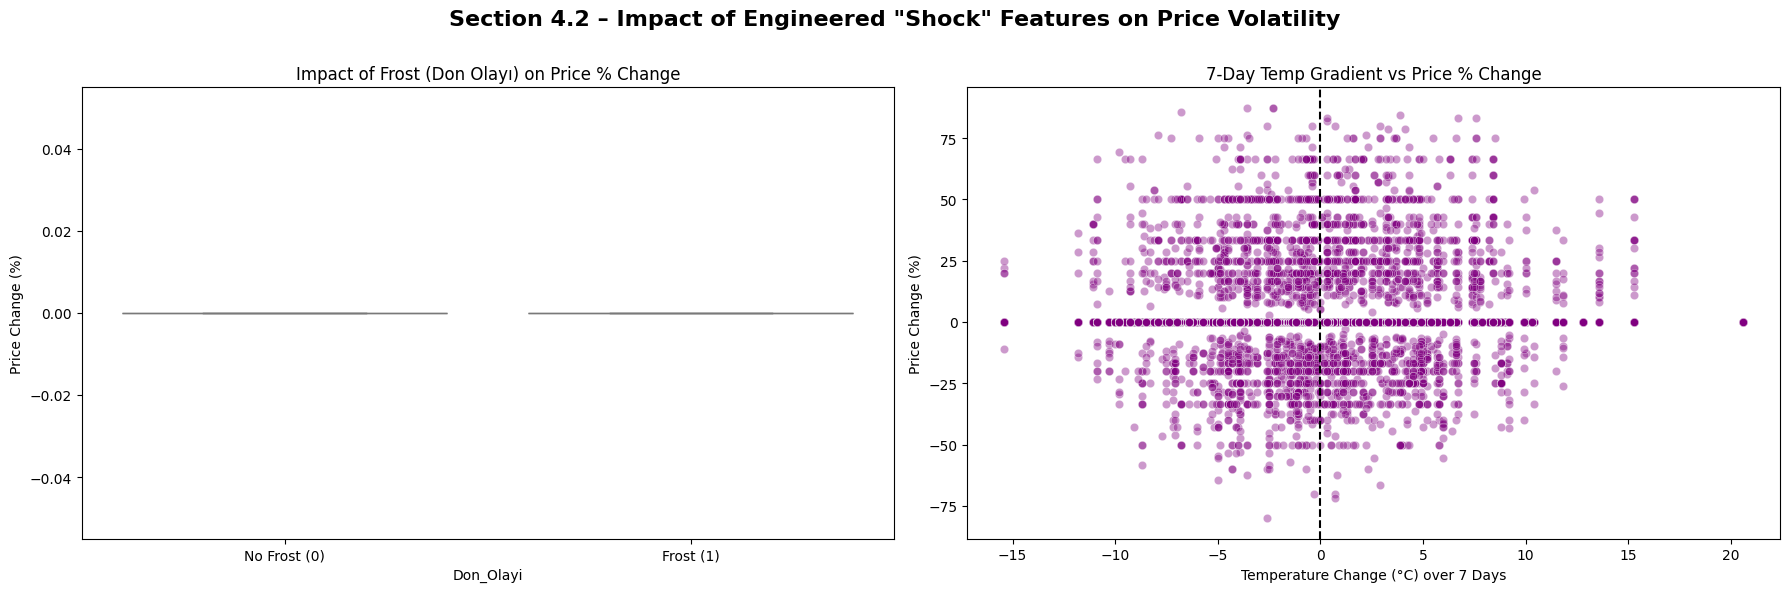

Ortalama Fiyat Değişimi - Normal Günler: %0.72
Ortalama Fiyat Değişimi - Don Olan Günler: %3.69


In [270]:
# —— Section 4.3: Validating Engineered Features ——

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Section 4.2 – Impact of Engineered "Shock" Features on Price Volatility', fontweight='bold', fontsize=16)

# 1. Don Olayı Etkisi (Box Plot)
# Don olan (1) ve olmayan (0) günler arasındaki fiyat değişim farkı
sns.boxplot(data=df_final, x='Don_Olayi', y='Fiyat_Degisim_Yuzdesi', ax=axes[0], palette='coolwarm', showfliers=False)
axes[0].set_title('Impact of Frost (Don Olayı) on Price % Change')
axes[0].set_xticklabels(['No Frost (0)', 'Frost (1)'])
axes[0].set_ylabel('Price Change (%)')

# 2. Sıcaklık Trendi Etkisi (Scatter Plot)
# Sıcaklık farkı (bugün - 7 gün önce) ile fiyat değişimi arasındaki ilişki
sns.scatterplot(data=df_final, x='Sicaklik_Trendi', y='Fiyat_Degisim_Yuzdesi', ax=axes[1], alpha=0.4, color='purple')
axes[1].set_title('7-Day Temp Gradient vs Price % Change')
axes[1].set_xlabel('Temperature Change (°C) over 7 Days')
axes[1].set_ylabel('Price Change (%)')
axes[1].axvline(0, color='black', linestyle='--') # Nötr çizgi

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# İstatistiki Kontrol
frost_impact = df_final.groupby('Don_Olayi')['Fiyat_Degisim_Yuzdesi'].mean()
print(f"Ortalama Fiyat Değişimi - Normal Günler: %{frost_impact[0]:.2f}")
print(f"Ortalama Fiyat Değişimi - Don Olan Günler: %{frost_impact[1]:.2f}")

### Section 4.4 – Feature Validation & Signal Analysis

Before proceeding to any modeling, we must verify if our engineered features contain any "predictive signal."
We will analyze:
1. **The Frost Factor:** Does sub-zero weather actually correlate with higher price volatility?
2. **Correlation Update:** How do the new features (Volatility, Trend, Shocks) relate to the target compared to raw weather data?

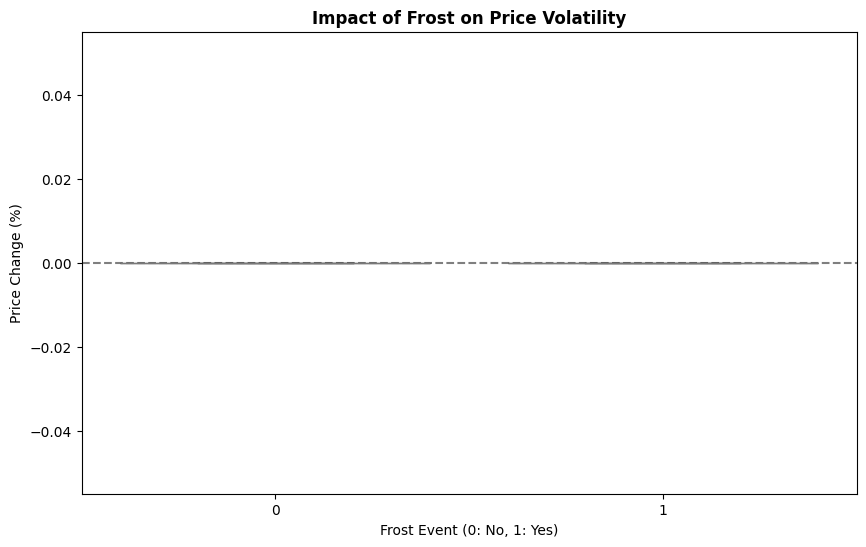

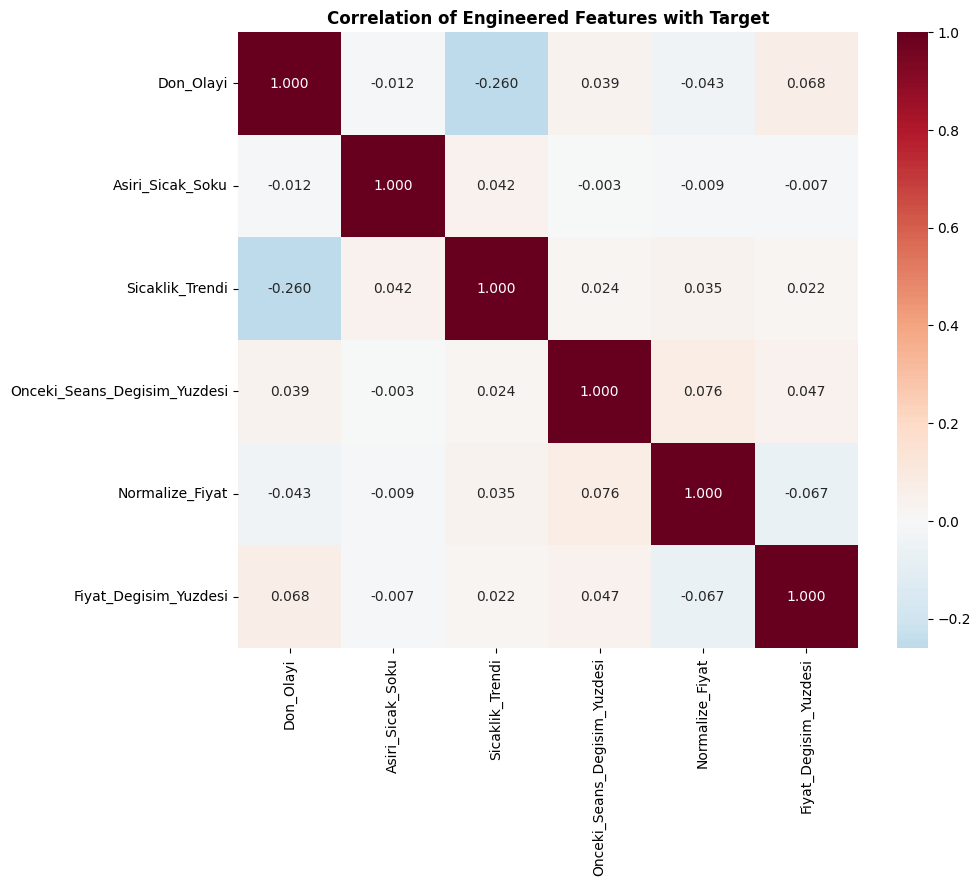

In [271]:
# —— Section 4.4: Feature Signal Analysis ——

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Don Olayı ve Fiyat Değişimi Arasındaki İlişki (Box Plot)
plt.figure(figsize=(10, 6))
# 'Don_Olayi' etkisini görebilmek için hedef değişkeni (y) kırılımlı inceliyoruz.
sns.boxplot(data=df_final, x='Don_Olayi', y='Fiyat_Degisim_Yuzdesi', palette='coolwarm', showfliers=False)
plt.title('Impact of Frost on Price Volatility', fontweight='bold')
plt.xlabel('Frost Event (0: No, 1: Yes)')
plt.ylabel('Price Change (%)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# 2. Güncellenmiş Korelasyon Analizi
# DÜZELTME: Sadece Section 4.2'de GERÇEKTEN ürettiğimiz yeni özellikleri listeye koyuyoruz.
new_features = ['Don_Olayi', 'Asiri_Sicak_Soku', 'Sicaklik_Trendi',
                'Onceki_Seans_Degisim_Yuzdesi', 'Normalize_Fiyat', 'Fiyat_Degisim_Yuzdesi']

corr_new = df_final[new_features].corr()

plt.figure(figsize=(10, 8)) # Daha rahat okunması için boyutu biraz büyüttük
sns.heatmap(corr_new, annot=True, cmap='RdBu_r', center=0, fmt=".3f")
plt.title('Correlation of Engineered Features with Target', fontweight='bold')
plt.show()

### Section 4.5 – Final Data Refinement & Stationarity

Before passing the data to Machine Learning algorithms, we perform two final checks:
1. **Visualizing Stationarity:** Confirming that price percentage changes fluctuate around a constant mean (crucial for regression stability).
2. **Outlier Removal:** Using the IQR (Interquartile Range) method to remove extreme price jumps that are likely data entry errors or extreme market anomalies.

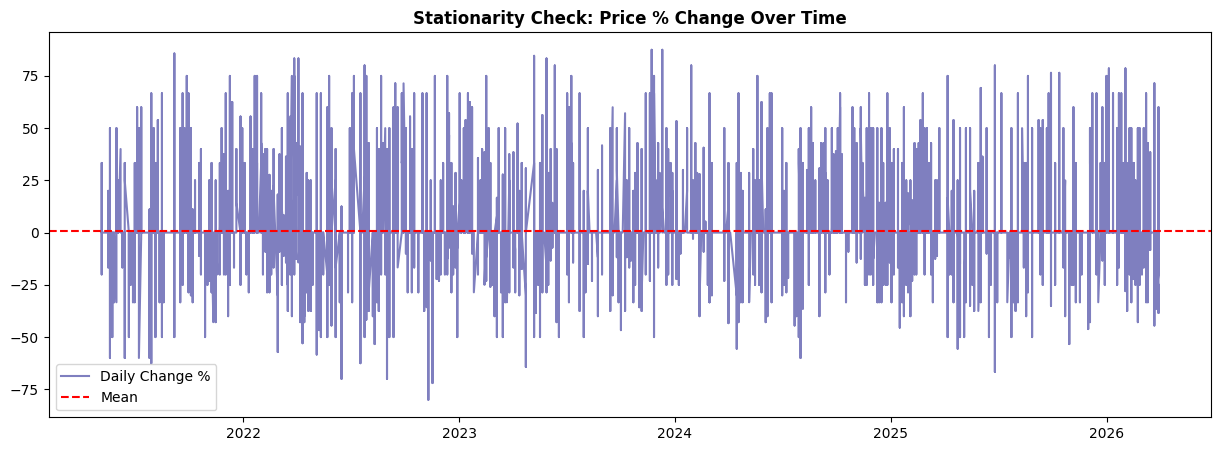

Orijinal Veri: 23187 | Temizlenmiş Veri: 20187
Temizlenen Aykırı Veri Sayısı: 3000


In [272]:
# —— Section 4.4: Final Refinement ——

# 1. Zaman Serisi Durağanlık Kontrolü (Visual Check)
plt.figure(figsize=(15, 5))
plt.plot(df_final['Tarih'], df_final['Fiyat_Degisim_Yuzdesi'], color='navy', alpha=0.5, label='Daily Change %')
plt.axhline(df_final['Fiyat_Degisim_Yuzdesi'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Stationarity Check: Price % Change Over Time', fontweight='bold')
plt.legend()
plt.show()

# 2. Aykırı Değerlerin (Outliers) Temizlenmesi
# Regresyon modelleri uç değerlere çok hassastır.
Q1 = df_final['Fiyat_Degisim_Yuzdesi'].quantile(0.25)
Q3 = df_final['Fiyat_Degisim_Yuzdesi'].quantile(0.75)
IQR = Q3 - Q1

# Sınırları belirliyoruz (Örn: %50'den fazla ani sapmaları temizleyebiliriz)
lower_bound = Q1 - 3 * IQR # Daha geniş bir sınır (extreme outliers)
upper_bound = Q3 + 3 * IQR

df_cleaned = df_final[(df_final['Fiyat_Degisim_Yuzdesi'] >= lower_bound) &
                      (df_final['Fiyat_Degisim_Yuzdesi'] <= upper_bound)]

print(f"Orijinal Veri: {len(df_final)} | Temizlenmiş Veri: {len(df_cleaned)}")
print(f"Temizlenen Aykırı Veri Sayısı: {len(df_final) - len(df_cleaned)}")

## Section 5 – Machine Learning Modeling & Evaluation

### Section 5.1: Chronological Validation Strategy (TimeSeriesSplit)
Unlike standard cross-sectional data, agricultural price movements are strictly time-dependent. Treating this dataset like a random collection of rows by applying a standard randomized split or `KFold` would destroy its chronological integrity.

Training on future market conditions to predict past prices creates a deceptive, unrealistic performance metric—akin to watching a movie out of order and claiming you predicted the plot. To enforce a rigorous, real-world forecasting scenario, we absolutely avoid random shuffling. Instead, we implement `TimeSeriesSplit`. This strictly causal cross-validation strategy ensures the model is *always* trained on historical data and validated on future, unseen data, providing a defensible and production-ready evaluation metric.

In [273]:
# —— Section 5.1: Data Splitting & Cross-Validation Setup ——

from sklearn.model_selection import TimeSeriesSplit

# 1. Veriyi Tarihe Göre Sıralama (Zaman akışını garantiye alıyoruz)
df_final = df_final.sort_values('Tarih').reset_index(drop=True)

# 2. X (Özellikler/Features) ve y (Hedef/Target) Belirleme
# Modelin görmemesi gereken target ve indeks niteliği taşıyan sütunları çıkarıyoruz.
drop_cols = ['Tarih', 'Ürün Adı', 'Fiyat_Degisim_Yuzdesi']
X = df_final.drop(columns=drop_cols)
y = df_final['Fiyat_Degisim_Yuzdesi']

# 3. Time Series Cross-Validation (Zaman Serisi Çapraz Doğrulama)
# Modeli geçmişle eğitip gelecekle test etmek için 5 fold'a bölüyoruz.
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"✅ Features (X) shape: {X.shape}")
print(f"✅ Target (y) shape: {y.shape}")
print(f"✅ Strategy: TimeSeriesSplit with {n_splits} splits (Chronological Order Maintained)\\n")

print("--- Validation Folds ---")
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Fold {i+1}: Train={len(train_index):<6} samples | Test={len(test_index):<5} samples")

✅ Features (X) shape: (23187, 65)
✅ Target (y) shape: (23187,)
✅ Strategy: TimeSeriesSplit with 5 splits (Chronological Order Maintained)\n
--- Validation Folds ---
Fold 1: Train=3867   samples | Test=3864  samples
Fold 2: Train=7731   samples | Test=3864  samples
Fold 3: Train=11595  samples | Test=3864  samples
Fold 4: Train=15459  samples | Test=3864  samples
Fold 5: Train=19323  samples | Test=3864  samples
